In [166]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.impute import IterativeImputer
from sklearn.impute import KNNImputer

In [167]:
pd.set_option('display.max_columns', None) 
pd.set_option('display.max_rows', None) 
df_datos_salud = pd.read_csv("datos_salud_habitos.csv", index_col = 0)

In [168]:
df_datos_salud.sample(6)

,Edad,Genero,IMC,Nivel_Actividad,Consumo_Alcohol,Fumador,Presion_Sistolica,Presion_Diastolica,Colesterol,Glucosa,Horas_Sueno,Pasos_Diarios,Satisfaccion_Vida,Enfermedad_Cronica
ID,,,,,,,,,,,,,,
NaN,65.0,Otro,36.35,Alto,Nunca,No,126.0,86.0,Muy Alto,119.3,6.8,14644.0,NaN,No
NaN,32.0,Femenino,26.97,Bajo,Frecuente,Sí,173.0,NaN,NaN,75.2,9.3,NaN,4.0,No
1079.0,NaN,Otro,37.00,Alto,Frecuente,No,155.0,77.0,Normal,76.8,7.2,18600.0,9.0,No
1196.0,78.0,Masculino,18.00,NaN,Ocasional,No,155.0,68.0,Muy Alto,112.8,8.8,8240.0,8.0,Sí
713.0,78.0,Masculino,NaN,Bajo,Ocasional,Sí,169.0,81.0,Normal,74.9,9.5,11774.0,3.0,Sí
519.0,43.0,Femenino,28.58,NaN,Nunca,Sí,133.0,75.0,Normal,94.4,NaN,1589.0,5.0,NaN


Pasamos la columna index a ID

In [169]:
df_datos_salud = df_datos_salud.reset_index()

-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

# ***1.-EDA***

Primero vamos a explorar y visualizar los datos para entender su estructura, detectar errores, valores atípicos, relaciones entre variables, etc.
Aplicaremos una función de EDA básico en nuestra BBDD

In [170]:
def eda_basico(df):

    print("========== RESUMEN GENERAL ==========")
    print("📐 Dimensiones:")
    print(f"Este DataFrame tiene {df.shape[0]} filas y {df.shape[1]} columnas." , "\n")
    print('-----------------------------------------------------')
    print("🧠 Información general:")


    display(df.info())
    print('-----------------------------------------------------', "\n")
    print("📊 Tipos de datos por columna:")

    
    print(df.dtypes, "\n")
    print('-----------------------------------------------------', "\n")
    
    print("\n========== DESCRIBES ==========")
    print("📉 Descripción de columnas numéricas:")
    display(df.describe().T)
    print('-----------------------------------------------------', "\n")
    
    print("🔤 Descripción de columnas categóricas:")
    try:
        display(df.describe(include=['O']).T)

    except ValueError:

        print("No se existen columnas categóricas en este DataFrame.")
    print('-----------------------------------------------------', "\n")

    print("\n========== MUESTRAS ==========")
    print("🔍 Primeras filas del DataFrame:")
    display(df.head(3))

    print("🔍 Últimas filas del DataFrame:")
    display(df.tail(3))

    print("🔍 Cinco filas aleatorias del DataFrame:")
    display(df.sample(3))
    print('-----------------------------------------------------', "\n")

    col_categoricas =  df.select_dtypes(include=["object"]).columns.tolist()


    print("\n========== NULOS ==========")
    print("🚫 Valores nulos por columna:") 
    lista_columnas = df.columns.tolist()
    for col in lista_columnas:
       
        print(f'{col} --> {df[col].isnull().mean()*100} % de valores nulos.')

    print('-----------------------------------------------------')

    print("\n========== DUPLICADOS ==========")

    print("📎 Filas duplicadas:")
    dup_count = df.duplicated().sum()
    print(f"Hay {dup_count} filas duplicadas.")
    
    if dup_count > 0:
        
        print("Ejemplo de duplicados:")
        display(df[df.duplicated()])

    else:
        print("No hay filas duplicadas.\n")
    print('-----------------------------------------------------')


    print("\n========== HISTOGRAMAS NUMÉRICOS ==========")

    df.hist(bins=20, figsize=(25,25))
    plt.show()
    print('-----------------------------------------------------')


    print("\n========== GRÁFICAS DE BARRAS CATEGÓRICAS==========")

    if col_categoricas:
        for c in col_categoricas:
            plt.figure(figsize=(10, 10))
            sns.countplot(x=c, data=df, palette='Set2')
            plt.xticks(rotation=90)
            plt.xlabel(f"Countplot de {c}")
            plt.show()
    else:
        print("No existen columnas categóricas a las que realizar gráficas de barras.")

        

========== RESUMEN GENERAL ==========
📐 Dimensiones:
Este DataFrame tiene 1200 filas y 15 columnas. 

-----------------------------------------------------
🧠 Información general:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   ID                  1080 non-null   float64
 1   Edad                1080 non-null   float64
 2   Genero              1080 non-null   object 
 3   IMC                 1080 non-null   float64
 4   Nivel_Actividad     1080 non-null   object 
 5   Consumo_Alcohol     1080 non-null   object 
 6   Fumador             1080 non-null   object 
 7   Presion_Sistolica   1080 non-null   float64
 8   Presion_Diastolica  1080 non-null   float64
 9   Colesterol          1080 non-null   object 
 10  Glucosa             1080 non-null   float64
 11  Horas_Sueno         1080 non-null   float64
 12  Pasos_Diarios       108

None

----------------------------------------------------- 

📊 Tipos de datos por columna:
ID                    float64
Edad                  float64
Genero                 object
IMC                   float64
Nivel_Actividad        object
Consumo_Alcohol        object
Fumador                object
Presion_Sistolica     float64
Presion_Diastolica    float64
Colesterol             object
Glucosa               float64
Horas_Sueno           float64
Pasos_Diarios         float64
Satisfaccion_Vida     float64
Enfermedad_Cronica     object
dtype: object 

----------------------------------------------------- 


========== DESCRIBES ==========
📉 Descripción de columnas numéricas:


,count,mean,std,min,25%,50%,75%,max
ID,1080.0,597.482407,346.386325,1.0,293.750,602.50,898.2500,1200.00
Edad,1080.0,49.597222,18.087774,18.0,34.000,50.00,66.0000,79.00
IMC,1080.0,29.179704,6.297420,18.0,23.995,29.26,34.6125,39.99
Presion_Sistolica,1080.0,135.182407,26.141929,90.0,112.000,136.00,158.0000,179.00
Presion_Diastolica,1080.0,89.352778,17.043057,60.0,75.000,89.00,104.0000,119.00
Glucosa,1080.0,132.714352,37.128472,70.1,100.400,132.45,162.8250,199.90
Horas_Sueno,1080.0,7.005278,1.669477,4.0,5.600,7.00,8.4000,10.00
Pasos_Diarios,1080.0,10583.525000,5576.661805,1005.0,5720.250,10471.00,15612.7500,19982.00
Satisfaccion_Vida,1080.0,4.935185,2.542587,1.0,3.000,5.00,7.0000,9.00


----------------------------------------------------- 

🔤 Descripción de columnas categóricas:


...

🔍 Últimas filas del DataFrame:


,ID,Edad,Genero,IMC,Nivel_Actividad,Consumo_Alcohol,Fumador,Presion_Sistolica,Presion_Diastolica,Colesterol,Glucosa,Horas_Sueno,Pasos_Diarios,Satisfaccion_Vida,Enfermedad_Cronica
1197,1198.0,32.0,Masculino,NaN,Bajo,Ocasional,No,162.0,82.0,Muy Alto,180.1,7.7,14536.0,5.0,No
1198,1199.0,64.0,Masculino,24.08,Alto,Nunca,No,116.0,94.0,Muy Alto,NaN,4.0,2600.0,NaN,No
1199,1200.0,73.0,NaN,33.55,Alto,Frecuente,NaN,NaN,NaN,Alto,72.3,5.1,6700.0,4.0,No


🔍 Cinco filas aleatorias del DataFrame:


,ID,Edad,Genero,IMC,Nivel_Actividad,Consumo_Alcohol,Fumador,Presion_Sistolica,Presion_Diastolica,Colesterol,Glucosa,Horas_Sueno,Pasos_Diarios,Satisfaccion_Vida,Enfermedad_Cronica
464,465.0,63.0,Otro,36.50,Moderado,NaN,Sí,164.0,109.0,Muy Alto,156.1,5.5,NaN,6.0,No
539,540.0,32.0,Otro,25.22,NaN,Nunca,Sí,145.0,NaN,Muy Alto,127.3,6.0,2942.0,6.0,No
765,NaN,40.0,Masculino,23.00,Alto,Frecuente,Sí,128.0,76.0,Alto,108.4,5.9,6302.0,9.0,Sí


----------------------------------------------------- 


========== NULOS ==========
🚫 Valores nulos por columna:
ID --> 10.0 % de valores nulos.
Edad --> 10.0 % de valores nulos.
Genero --> 10.0 % de valores nulos.
IMC --> 10.0 % de valores nulos.
Nivel_Actividad --> 10.0 % de valores nulos.
Consumo_Alcohol --> 10.0 % de valores nulos.
Fumador --> 10.0 % de valores nulos.
Presion_Sistolica --> 10.0 % de valores nulos.
Presion_Diastolica --> 10.0 % de valores nulos.
Colesterol --> 10.0 % de valores nulos.
Glucosa --> 10.0 % de valores nulos.
Horas_Sueno --> 10.0 % de valores nulos.
Pasos_Diarios --> 10.0 % de valores nulos.
Satisfaccion_Vida --> 10.0 % de valores nulos.
Enfermedad_Cronica --> 10.0 % de valores nulos.
-----------------------------------------------------

========== DUPLICADOS ==========
📎 Filas duplicadas:
Hay 0 filas duplicadas.
No hay filas duplicadas.

-----------------------------------------------------

========== HISTOGRAMAS NUMÉRICOS ==========


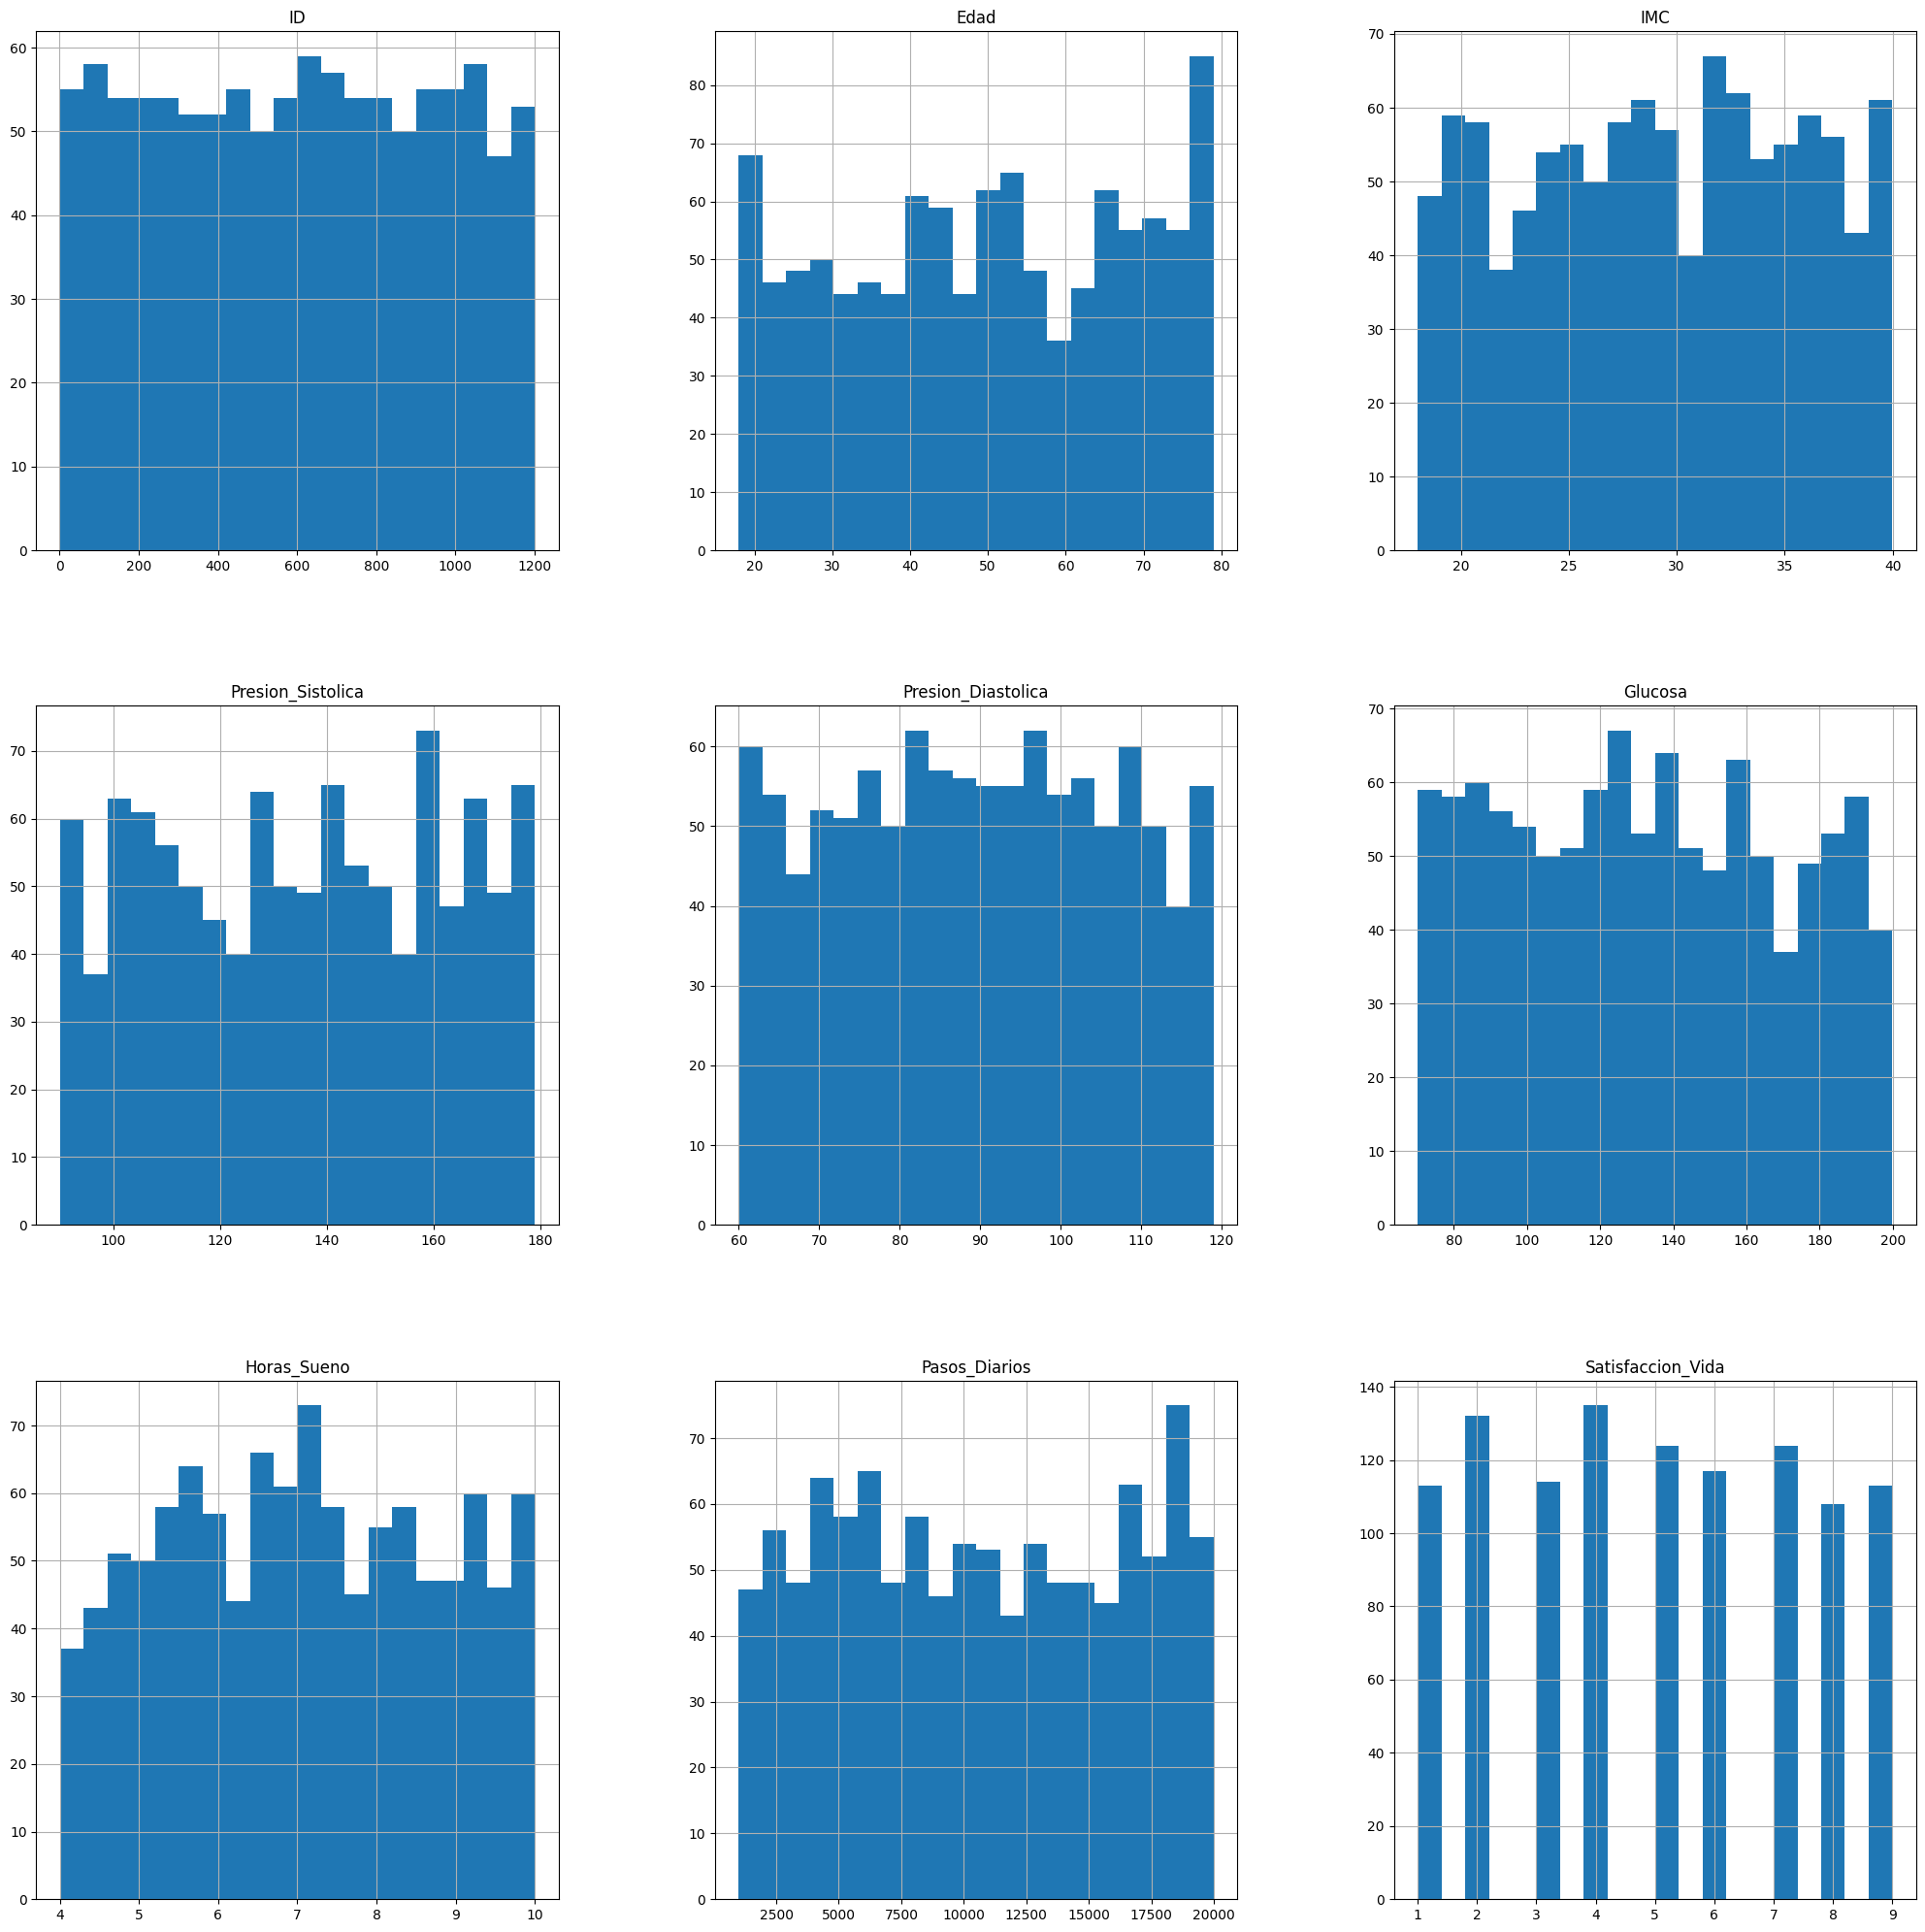

-----------------------------------------------------

========== GRÁFICAS DE BARRAS CATEGÓRICAS==========


C:\Users\elena\AppData\Local\Temp\ipykernel_12456\241371315.py:83: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=c, data=df, palette='Set2')


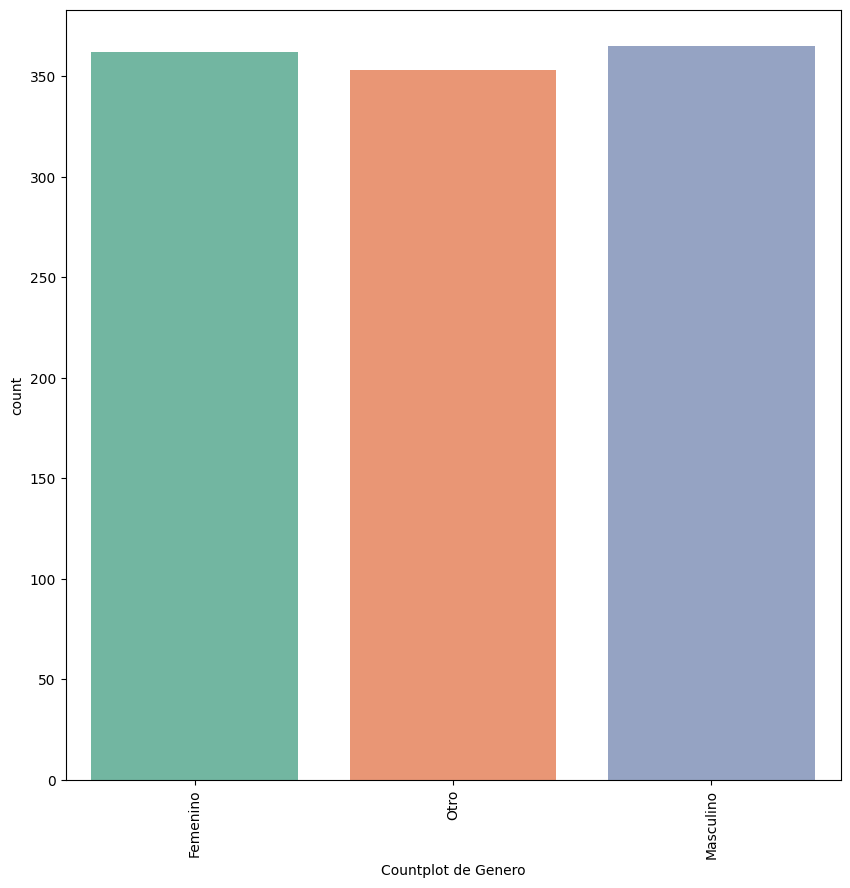

C:\Users\elena\AppData\Local\Temp\ipykernel_12456\241371315.py:83: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=c, data=df, palette='Set2')


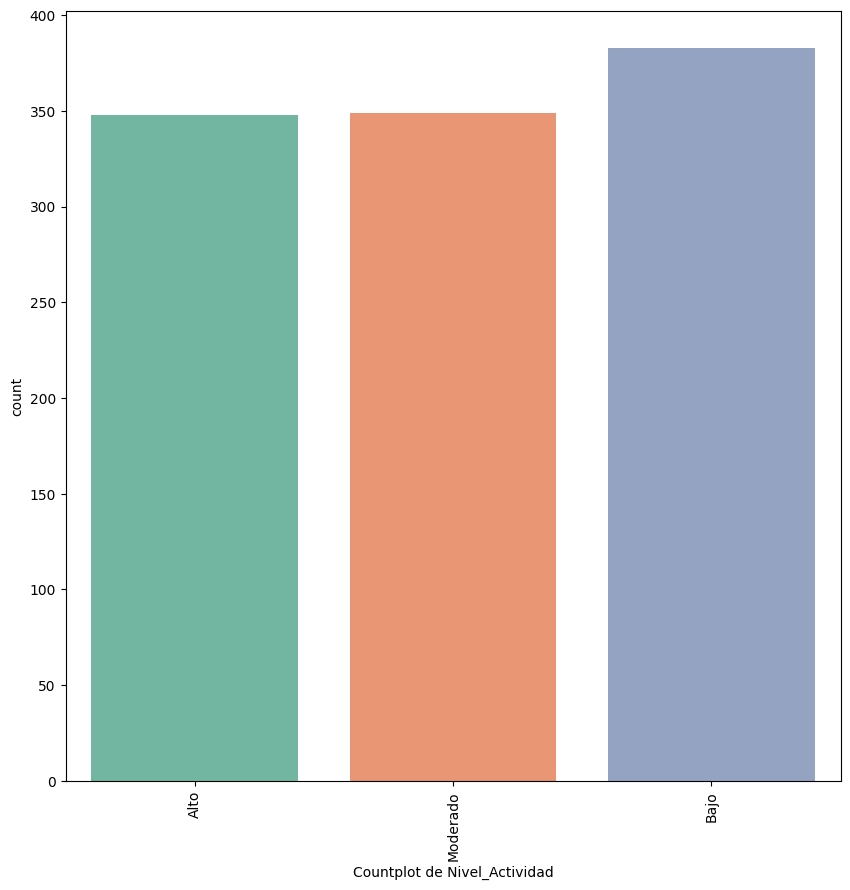

C:\Users\elena\AppData\Local\Temp\ipykernel_12456\241371315.py:83: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=c, data=df, palette='Set2')


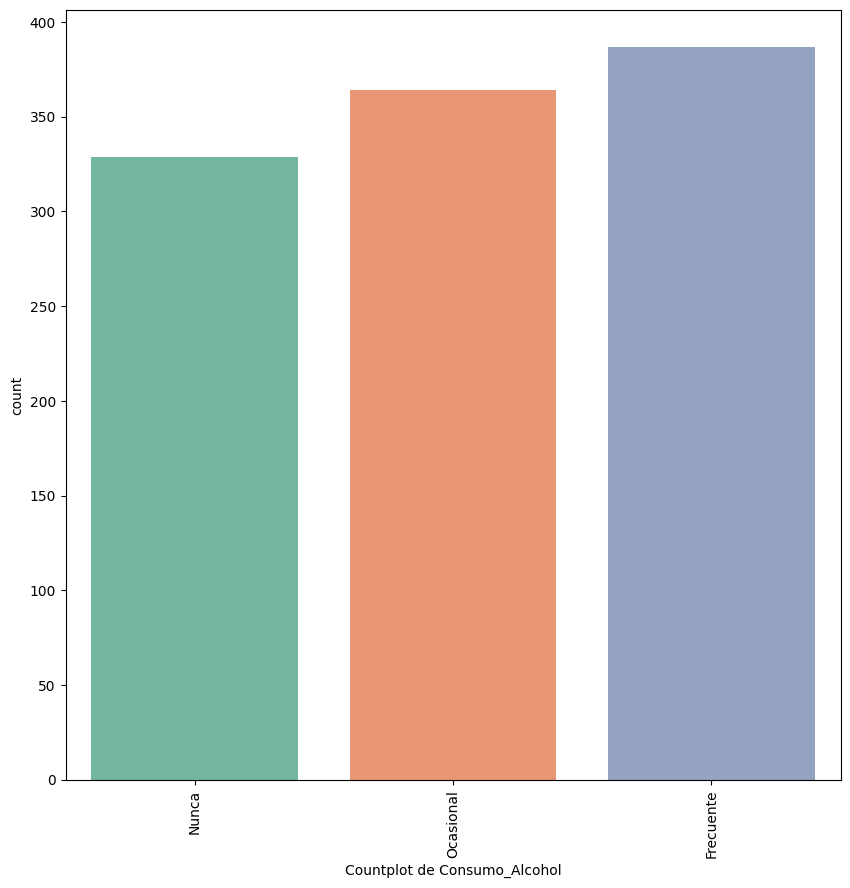

C:\Users\elena\AppData\Local\Temp\ipykernel_12456\241371315.py:83: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=c, data=df, palette='Set2')


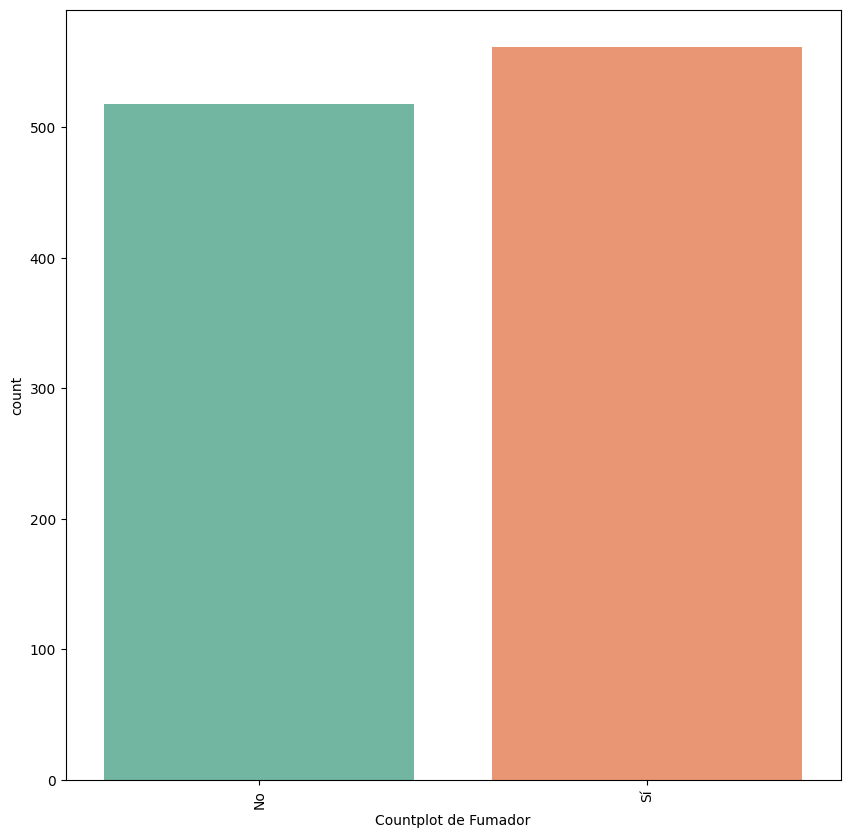

C:\Users\elena\AppData\Local\Temp\ipykernel_12456\241371315.py:83: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=c, data=df, palette='Set2')


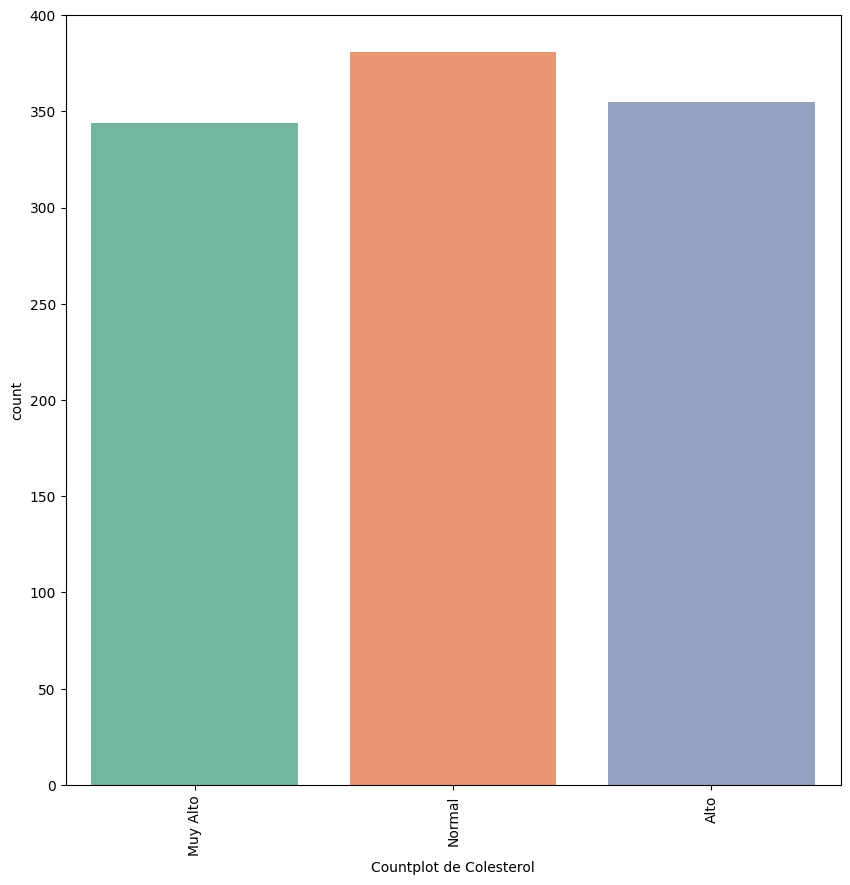

C:\Users\elena\AppData\Local\Temp\ipykernel_12456\241371315.py:83: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=c, data=df, palette='Set2')


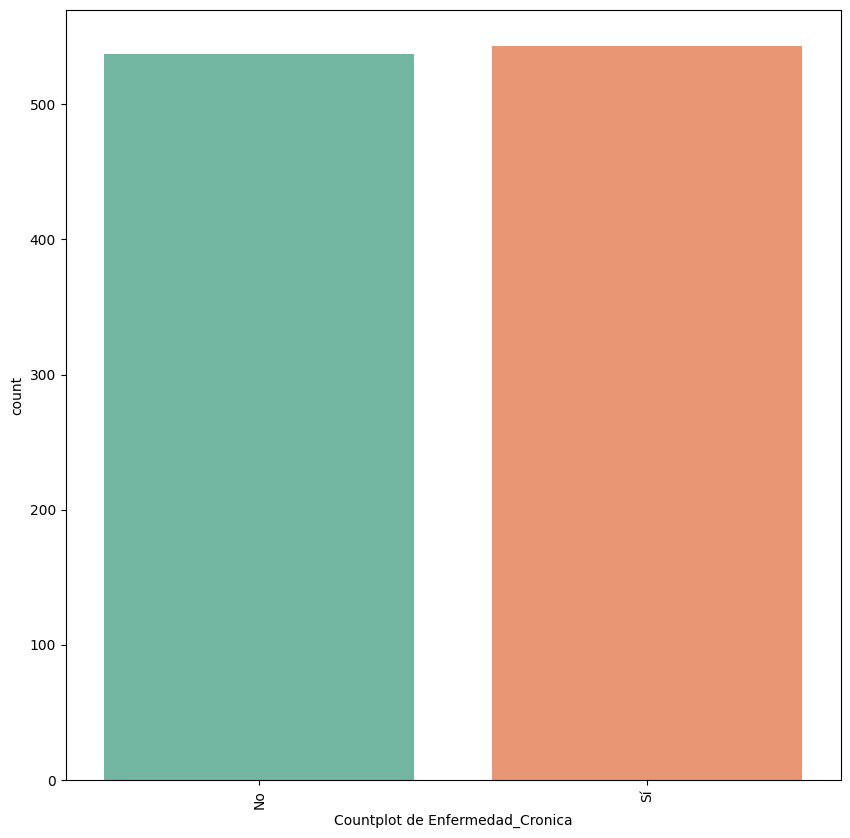

In [171]:
eda_basico(df_datos_salud)

## ***1.1-Analisis de los visto en el EDA***

Este conjunto de datos llamado "datos_salud_habitos" reúne la información de 1080 personas, nos da una visión general de su salud, estilo de vida y bienestar.

Para el análisis del describe, nos apoyamos en criterios médicos para evaluar si, por ejemplo, los valores de IMC, glucosa o presión arterial se encontraban dentro de rangos saludables.

## *VARIABLES NUMÉRICAS*

A continuación haremos un análisis descriptivo de las **variables numéricas**:

####    *_Edad_*
La media de edad que podemos observar es de 49 años (49,6 para ser exactos), todas las personas son mayores de edad, el rango va desde los 18 hasta los 79 años. Esto nos deja ver que la muestra es equilibrada entre adultos jóvenes y mayores, sin valores extremos.

####    *_IMC_*
El valor medio es de 29,2, algo por encima de lo que se considera un rango saludable, esto indica una tendencia general hacia el "sobrepeso". Hay un 75% de la muestra que presentan un IMC igual o inferior al 34,6, lo que nos deja ver que la presencia de obesidad moderada en parte de la muestra.

####    *_Presion_Sistolica_*
La media de la presión sistólica es de 135 (135,18), este valor está algo por encima de  de los niveles que se consideran normales, lo que nos hace pensar que pudiera existir una ligera tendencia a la hipertensión leve.

####    *_Presión_Diastólica_*
Si ahora analizamos la media de la presión diastólica es de 89, este valor (al igual que la presión sistólica) está algo por encima de  de los niveles que se consideran normales, lo que nos hace pensar que pudiera existir una ligera tendencia a la hipertensión leve.

####    *_Glucosa_*
Como vemos, la media de la glucosa en la muestra es de 132,7 lo que nos indica que los niveles de glucosa son relativamente altos. Puede ser debido a que tenemos minimos y máximos muy extremos, puede ser que la muestra mezcle a personas sanas con personas que sufren de enfermedades relacionadas a la glucosa.

####    *_Horas_Sueno_*
La media es de 7 horas por noche, siendo 4 el minimo de horas dormidas frente a 10. La mayoría duerme una cantidad considerada adecuada (entre 7 y 9), pero siguen mostrando minimos y máximos contrapuesto, mostrando un déficit o exceso de sueño.

####    *_Pasos_Diarios_*
La media de pasos está en 10.584 con una variabilidad amplia. La mediana (10.471 pasos) sugiere que el grupo mantiene un nivel de actividad física moderado o incluso alto, aunque hay diferencias claras entre personas más activas y más sedentarias.

####    *_Satisfaccion_Vida_*
La puntación promedio de nuestra muestra es (de una esscala del 1 al 9) 4,9. Lo que podemos decir con este dato es que están moderadamente satisfechos aunque hay datos muy contrapuestos, hay bastantes personas con una nota baja y otras con alto nivel de bienestar.



### ***_Conclusión Final_***

La muestra está compuesta por personas adultas que, en general, presentan una tendencia al sobrepeso, así como niveles algo elevados de presión arterial y glucosa. A pesar de esto, mantienen buenos hábitos tanto de sueño como de actividad física. En cuanto a la satisfacción con la vida, se sitúa en un punto medio, lo que refleja una variedad de percepciones sobre sus propios estilos de vida.

## *VARIABLES CATEGÓRICAS*

A continuación haremos un análisis descriptivo de las **variables categóricas**:

####    *_Genero_*
Como podemos observar cuenta con 3 categorías (Hombre, Mujer, Otro), en este caso el mayoritario es "Hombres" con 365 casos, aunque no hay una diferencia significativa entre las categorías.

####    *_Nivel_Actividad_*
El nivel de actividad mas frecuente es "Bajo" con 383 personas, lo que indica que hay una parte muy importante de la población que mantiene niveles bajos de actividad física. El resto se reparten entre las categorías "Moderada" y "Alta".

####    *_Consumo_Alcohol_*
El hábito mas repetido es el "Frecuente" con 387 personas lo que indica que es un dato común entre las personas que forman la muestra pero no necesariamente excesivo, no llega a niveles preocupantes.

####    *_Fumador_*
Más de la mitad de las personas fuman (562 casos frente a 518 que no), lo que señala un comportamiento de riesgo predominante.

####    *_Colesterol_*
La mayoría presenta niveles normales de colesterol (381 casos), mientras que el resto se distribuye entre niveles “Altos” y “Muy Altos”. En conjunto, esto sugiere un perfil relativamente equilibrado.

####    *_Enfermedad_Cronica_*
Casi la mitad de las personas declaran tener una enfermedad crónica (543 casos), esto refleja una prevalencia significativa de problemas de salud prolongados dentro de la muestra.



### ***_Conclusión Final_***

En conjunto, los datos muestran una población con alta prevalencia de factores de riesgo (fumadores, baja actividad física y presencia de enfermedades crónicas), pero con ciertos indicadores (como el colesterol) aún dentro de rangos normales para muchas personas.



-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

# ***2.-LIMPIEZA***

##### Para igualar los datos ponemos las columnas en minúsculas y dejamos, en lugar de espacio, un guión bajo para separar varias palabras:

In [172]:
df_datos_salud.columns = df_datos_salud.columns.str.lower()

### ------------------------ _COLUMNAS NUMERICAS_ --------------------------

#### Conversión de columnas de tipo float64 a int64

Visto el EDA en el apartado anterior, decidimos cambiar varias columnas de tipo **float64** a **int64**, ya que los valores se representan mejor como enteros y no necesitan decimales:

- **`id`** — Cambiamos esta columna porque se trata de un número de identificación, que no debe tener decimales.

- **`edad`** — Al igual que la columna anterior, no necesitamos decimales, ya que las edades de las personas se miden en años enteros.

- **`satisfaccion`** — Esta columna es una escala del 1 al 9, por lo que se califica con números enteros, sin necesidad de decimales.

- **`pasos`** — Consideramos que tampoco necesitamos decimales, ya que se mide el número de pasos diarios como entero.



In [173]:
def convertir_int(df):
    columnas = ['id','edad','satisfaccion_vida','pasos_diarios']
    for col in columnas:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce').astype('Int64')
    return df

In [174]:
df_datos_salud = convertir_int(df_datos_salud)

### ------------------------ _COLUMNAS CATEGÓRICAS_ --------------------------

In [175]:
def ver_categoricas(df):

    cat_cols = df.select_dtypes(include=['object', 'category']).columns
   
    for col in cat_cols:
        print(f"\n Columna Categórica: '{col}'")
        print(df[col].unique())
        print("-----------------------------------------")

In [176]:
ver_categoricas(df_datos_salud)


 Columna Categórica: 'genero'
['Femenino' 'Otro' nan 'Masculino']
-----------------------------------------

 Columna Categórica: 'nivel_actividad'
['Alto' 'Moderado' 'Bajo' nan]
-----------------------------------------

 Columna Categórica: 'consumo_alcohol'
['Nunca' 'Ocasional' 'Frecuente' nan]
-----------------------------------------

 Columna Categórica: 'fumador'
['No' nan 'Sí']
-----------------------------------------

 Columna Categórica: 'colesterol'
['Muy Alto' 'Normal' 'Alto' nan]
-----------------------------------------

 Columna Categórica: 'enfermedad_cronica'
[nan 'No' 'Sí']
-----------------------------------------


##### En esta parte vemos los valores que están en las columnas categóricas y son coherentes, en la gestión de nulos decidiremos qué haremos con los "NaN" de cada columna.

-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

# ***NULOS***

##### Aplicamos una función para que nos de un dataframe con un resumen de los nulos de cada columna y su porcentaje, asi nos será mas claro a la hora de gestionarlos

In [177]:
porcentaje_nulos = (df_datos_salud.isnull().sum() / df_datos_salud.shape[0]) * 100

# Añadimos el total del sumatorio de nulos
total_nulos = df_datos_salud.isnull().sum()

# Convertimos la serie en un DataFrame con una columna llamada "Porcentaje nulos" 

df_nulos = pd.DataFrame({
    "Total nulos": total_nulos,
    "Porcentaje nulos": porcentaje_nulos,
    "Tipo de dato": df_datos_salud.dtypes})

# Añadimos el tipo de dato de cada columna

df_nulos["Tipo de dato"] = df_datos_salud.dtypes

# Filtramos solo las columnas que tienen al menos un nulo (> 0%), redondeamos, ordenamos y ponemos reset_index() para que nos salga en formato DataFrame

df_nulos = df_nulos[df_nulos["Porcentaje nulos"] > 0].round(2).reset_index().sort_values(by="Porcentaje nulos", ascending=False)

# Renombramos las columnas para que el resultado sea claro

df_nulos.columns = ["Columna", "Total nulos", "Porcentaje nulos", "Tipo de dato"]

# Llamamos al DataFrame para comprobar

df_nulos

,Columna,Total nulos,Porcentaje nulos,Tipo de dato
0,id,120,10.0,Int64
1,edad,120,10.0,Int64
2,genero,120,10.0,object
3,imc,120,10.0,float64
4,nivel_actividad,120,10.0,object
5,consumo_alcohol,120,10.0,object
6,fumador,120,10.0,object
7,presion_sistolica,120,10.0,float64
8,presion_diastolica,120,10.0,float64
9,colesterol,120,10.0,object


Ahora que tenemos este Dataframe, queremos ver las filas que tienen algún nulo en ellas, por si acaso hay filas que tengan muchos nulos en ellas y podemos hacer otro tipo de gestión.

In [178]:
df_datos_salud[df_datos_salud.isna().any(axis=1)].sample(10)

,id,edad,genero,imc,nivel_actividad,consumo_alcohol,fumador,presion_sistolica,presion_diastolica,colesterol,glucosa,horas_sueno,pasos_diarios,satisfaccion_vida,enfermedad_cronica
596,597,<NA>,NaN,34.71,Alto,Nunca,Sí,138.0,68.0,Muy Alto,82.2,8.9,6278,2,Sí
920,921,37,Femenino,19.12,NaN,Nunca,Sí,166.0,109.0,Alto,160.2,NaN,15837,9,No
1107,1108,46,Masculino,18.42,NaN,Nunca,No,125.0,117.0,Normal,111.2,NaN,18669,7,No
349,350,42,Masculino,20.41,Bajo,Nunca,No,174.0,103.0,Alto,NaN,6.7,4667,3,Sí
740,741,78,Masculino,36.22,Alto,Frecuente,No,NaN,82.0,Alto,142.9,10.0,6984,8,No
1010,1011,51,NaN,26.54,Bajo,Nunca,No,173.0,93.0,Alto,127.3,9.7,<NA>,4,No
414,415,50,Femenino,35.04,Moderado,Ocasional,NaN,140.0,92.0,Alto,86.3,5.9,11048,8,No
642,643,63,Otro,28.66,Moderado,Ocasional,NaN,105.0,65.0,Muy Alto,138.6,6.4,9391,8,Sí
9,10,75,Otro,27.95,Bajo,Nunca,Sí,170.0,65.0,Alto,NaN,NaN,14429,3,NaN
776,<NA>,39,Otro,38.64,Moderado,NaN,Sí,NaN,69.0,Normal,111.1,7.0,2806,5,No


## Tratamiento de valores nulos

Tras observar la tabla de valores nulos y aplicar la función para visualizar las filas afectadas con NaN, comprobamos que aproximadamente un 10% del conjunto de datos presenta valores faltantes.  
A pesar de ello, todas las filas contienen información relevante en otras columnas, por lo que **no resulta queremos eliminar estos registros**

Dado que el porcentaje de datos ausentes es moderado y la pérdida de información podría afectar al análisis, optamos por **gestionar los valores nulos** en lugar de descartarlos. Para ello, abordaremos las columnas según su tipo de dato:

- **Variables numéricas**: se imputarán utilizando medidas estadísticas como la **media** o la **mediana**, con el objetivo de mantener la coherencia de las distribuciones originales.

- **Variables categóricas**: se completarán empleando el **valor más frecuente** (moda) o una categoría genérica como `"Sin dato"`, que permita conservar el registro sin distorsionar los resultados.

Con este propósito, se crearán **dos funciones específicas**:  
una para el tratamiento de los valores nulos **numéricos** y otra para los valores nulos **categóricos**, lo que permitirá aplicar un proceso de limpieza controlado y coherente con la naturaleza de cada variable.

### ----------------------- _COLUMNAS NUMÉRICAS_ --------------------------------

##### _Vamos a comprobra a continuación el % de nulos de cada columna numérica, a raíz del resultado decidieremos qué hacer en cada una:_

### Tratamiento de valores nulos en columnas numéricas

Todas las columnas coinciden en tener un 10% de valores nulos, por lo que se ha decidido imputar los datos faltantes en lugar de eliminar registros, manteniendo así la integridad del conjunto. Las decisiones de imputación se han tomado tras analizar los histogramas generados en el EDA, que permiten observar la distribución de cada variable y elegir el método más adecuado. A continuación se detallan las decisiones:

- **`id`**  En este caso, como el ID es nulo pero los datos no se quieren perder, y al ser un identificador único y no una variable de análisis, se completará de forma **correlativa** para mantener la coherencia del índice sin afectar los datos del estudio.Se ha creado una función que busca los valores NaN y les asigna un número consecutivo al último ID existente.

- **`edad`**  Se imputará con la **mediana**, ya que el histograma mostró una distribución ligeramente sesgada. Este método conserva la representatividad de la muestra sin distorsionar la distribución de edades.

- **`imc`**  Se imputará con la **mediana**, dado que el índice de masa corporal presentó valores extremos en los histogramas. La mediana permite mantener la tendencia central sin verse afectada por outliers.

- **`presion_sistolica`**  Se imputará con la **mediana**, ya que los histogramas evidenciaron una alta variabilidad entre individuos. Usar la mediana evita que los valores extremos afecten el resultado y mantiene el valor central del grupo.

- **`presion_diastolica`**  Se imputará también con la **mediana**, por el mismo motivo que la presión sistólica: mantener la robustez frente a valores atípicos observados en la distribución.

- **`glucosa`**  Se imputará con la **mediana**, ya que los histogramas mostraron una distribución sesgada hacia valores altos. La mediana ayuda a evitar distorsiones y mantiene la coherencia de los datos clínicos.

- **`horas_sueno`**  Se imputará con la **media**, ya que el histograma mostró una distribución aproximadamente normal, sin presencia significativa de outliers. Este método refleja mejor la tendencia general de descanso diario en la muestra y conserva la varianza original.

- **`pasos_diarios`**  Se imputará con la **mediana**, dado que esta variable presentó gran dispersión en los histogramas (personas muy activas frente a sedentarias). La mediana evita que los valores extremos modifiquen la tendencia central.

- **`satisfaccion_vida`**  Se imputará con la **mediana**, porque se trata de una escala discreta de números enteros y ordinal, donde la mediana refleja mejor el valor típico observado en la distribución.

Finalmente, se aplicará una **función de imputación personalizada** para realizar estos reemplazos de forma ágil y controlada.

No se han aplicado técnicas avanzadas de imputación (como KNN por ejemplo) debido al **bajo porcentaje de nulos** y a que las distribuciones observadas en el EDA permiten una imputación simple pero efectiva, sin introducir ruido ni complejidad innecesaria.


In [179]:
def imputar_numericas(df):

    # Imputar los nulos de IDs 
    
    if 'id' in df.columns:
        max_id = df['id'].max()
        
        df.loc[df['id'].isna(), 'id'] = range(max_id + 1, max_id + 1 + df['id'].isna().sum())

    # Imputación de mediana

    for col in ['edad', 'imc', 'presion_sistolica', 'presion_diastolica', 'glucosa', 'pasos_diarios', 'satisfaccion_vida']:
        if col in df.columns:
            df[col] = df[col].fillna(df[col].median())
    
    # Imputación de media

    if 'horas_sueno' in df.columns:
        df['horas_sueno'] = df['horas_sueno'].fillna(df['horas_sueno'].mean())

    return df

In [180]:
df_datos_salud = imputar_numericas(df_datos_salud)

### ------------------------ _COLUMNAS CATEGÓRICAS_ --------------------------

### Tratamiento de valores nulos en columnas categóricas

Todas las columnas categóricas coinciden en tener un porcentaje bajo de valores nulos, por lo que se ha decidido imputar los datos incompletos en lugar de eliminar registros, manteniendo así la integridad del conjunto.

Lo que haremos es añadir una nueva categoría denominada **"Desconocido"**, que representa los casos no registrados o no declarados. Esta permite conservar toda la información disponible y mantener la representatividad de la muestra.

La elección de esta categoría se ha tomado tras analizar las gráficas de barras generadas en el EDA, que muestran la frecuencia de cada valor en las variables categóricas. Aunque en algunos casos la moda podría haber sido una opción válida (por ejemplo, si una categoría domina claramente), se ha optado por **no imputar con la moda** para **evitar introducir sesgo hacia una categoría específica**. Imputar con la moda puede alterar la distribución real y hacer que el modelo aprenda patrones artificiales.

En cambio, imputar con "Desconocido":

- No favorece ninguna categoría existente.
- Permite conservar la información de que el dato estaba ausente.
- Es útil en modelos de clasificación, donde "Desconocido" puede tener valor propio.

Las decisiones de imputación se detallan a continuación:

- **`genero`** — Se imputarán los valores nulos con la categoría "Desconocido".  

- **`nivel_actividad`** — Se imputarán los valores nulos con la categoría "Desconocido". 

- **`consumo_alcohol`** — Se imputarán los valores nulos con la categoría "Desconocido". 

- **`fumador`** — Se imputarán los valores nulos con la categoría "Desconocido".  

- **`colesterol`** — Se imputarán los valores nulos con la categoría "Desconocido".  

- **`enfermedad_crónica`** — Se imputarán los valores nulos con la categoría "Desconocido".  

Finalmente, se aplicará una única función para asignar la categoría "Desconocido" a todos los valores nulos de estas columnas, agilizando el proceso y manteniendo consistencia en el tratamiento de datos.

Cabe destacar que no se han aplicado técnicas avanzadas de imputación por el bajo porcentaje de nulos y a que los gráficos del EDA muestran **distribuciones claras** que **permiten una imputación simple, efectiva y sin distorsión**.

In [181]:
def imputar_categoricas(df):
   
    df_copy = df.copy()

    for col in ['genero', 'nivel_actividad', 'consumo_alcohol', 'colesterol', 'fumador', 'enfermedad_crónica']:
        if col in df_copy.columns:
            df_copy[col] = df_copy[col].fillna('Desconocido')
      
    return df_copy


In [182]:
df_datos_salud=imputar_categoricas(df_datos_salud)

In [183]:
df_datos_salud.sample(20)

,id,edad,genero,imc,nivel_actividad,consumo_alcohol,fumador,presion_sistolica,presion_diastolica,colesterol,glucosa,horas_sueno,pasos_diarios,satisfaccion_vida,enfermedad_cronica
696,697,60,Femenino,24.97,Desconocido,Frecuente,No,108.0,106.0,Normal,192.80,4.100000,6415,7,No
659,660,75,Femenino,21.62,Alto,Frecuente,Sí,133.0,89.0,Alto,166.40,9.600000,19228,6,No
867,868,61,Masculino,34.36,Bajo,Frecuente,No,178.0,113.0,Desconocido,138.90,4.800000,11419,2,Sí
252,1221,79,Femenino,29.34,Bajo,Frecuente,No,144.0,114.0,Alto,192.70,7.500000,1663,4,No
656,657,47,Masculino,35.30,Moderado,Nunca,No,173.0,110.0,Alto,130.20,5.800000,12573,6,NaN
1081,1082,56,Masculino,29.26,Desconocido,Ocasional,No,171.0,84.0,Muy Alto,95.30,7.005278,4811,9,No
1176,1177,26,Femenino,31.75,Bajo,Nunca,Sí,103.0,65.0,Muy Alto,176.20,8.900000,9637,7,NaN
339,340,50,Masculino,34.73,Alto,Ocasional,No,100.0,70.0,Muy Alto,110.30,9.200000,3395,4,No
1186,1187,65,Desconocido,35.06,Desconocido,Ocasional,Sí,176.0,92.0,Normal,137.70,9.500000,13008,5,Sí
521,522,42,Femenino,30.76,Alto,Frecuente,No,98.0,94.0,Alto,97.50,4.700000,19268,4,No


-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

# Guardamos CSV

In [184]:
df_datos_salud.to_csv('df_datos_salud_clean.csv', index=False)